# Understanding and using `slicersim.scene.Scene`
This notebook explains what a `slicersim.scene.Scene` object is, how to create one, and how to customize it.

## 1. What is a `Scene`?
A `Scene` in `slicersim` represents what the telescope is observing. It is composed of up to three elements:
- **target**: A point source, like a supernova or a standard star.
- **background**: A uniform background, like the zodiacal light.
- **host**: A structured background, like the host galaxy of a supernova (not yet implemented).

## 2. Creating a `Scene` from a configuration dictionary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from slicersim.scene.scene import Scene
from slicersim.scene.pointsource import get_snia_pointsource

In [6]:
config = {
    'pointsource': get_snia_pointsource(model='salt', redshift=0.5, position=(0,0)),
    'background': {'name': 'zodi', 'model': 'Aldering01.BB5800'}
}
lbda = np.linspace(4000, 17000, 1000)

In [7]:
scene = Scene.from_config(config, lbda=lbda)

In [8]:
print(scene.pointsource)
print(scene.background)

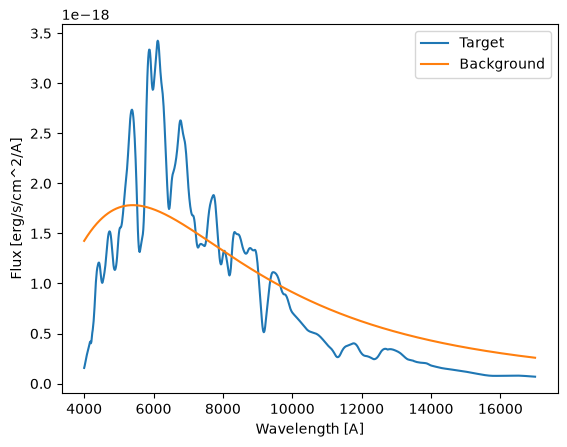

In [11]:
fig, ax = plt.subplots()
ax.plot(lbda, scene.pointsource.get_spectrum(lbda=lbda)[1], label='Target')
ax.plot(lbda, scene.background.get_spectrum(lbda=lbda)[1], label='Background')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/A]')
ax.legend()
plt.show()

## 3. Creating a `Scene` manually

In [12]:
from slicersim.scene.pointsource import PointSource, get_saltmodel_flux
from slicersim.scene.background import Background, zodiacal_spectrum

In [17]:
target = PointSource(model_func=get_saltmodel_flux, 
                     position=(0,0), 
                     meta={'redshift': 0.5, 'phase': 0})

background = Background(model_func=zodiacal_spectrum, 
                        meta={'model': 'Aldering01.BB5800'})

In [20]:
scene_manual = Scene(pointsource=target, background=background)

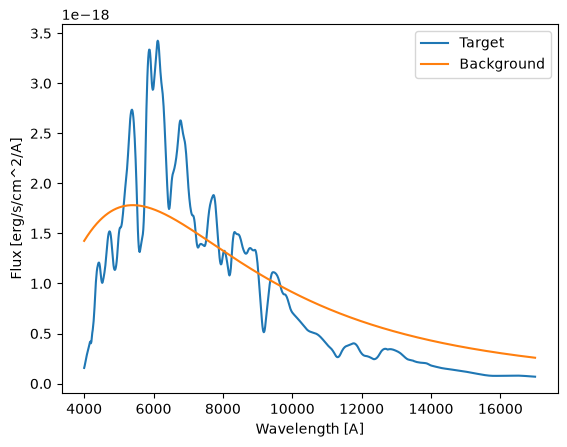

In [22]:
fig, ax = plt.subplots()
ax.plot(lbda, scene_manual.pointsource.get_spectrum(lbda=lbda)[1], label='Target')
ax.plot(lbda, scene_manual.background.get_spectrum(lbda=lbda)[1], label='Background')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux [erg/s/cm^2/A]')
ax.legend()
plt.show()

## 4. Creating a custom `PointSource` from a spectrum

In [23]:
# Create a dummy spectrum
lbda_custom = np.linspace(3000, 9000, 500)
flux_custom = np.exp(-((lbda_custom - 6000) / 100)**2)

In [24]:
custom_target = PointSource.from_spectrum(lbda_custom, flux_custom, mag=20, band='bessellb', position=(0,0))

In [26]:
scene_custom = Scene(pointsource=custom_target, lbda=lbda)

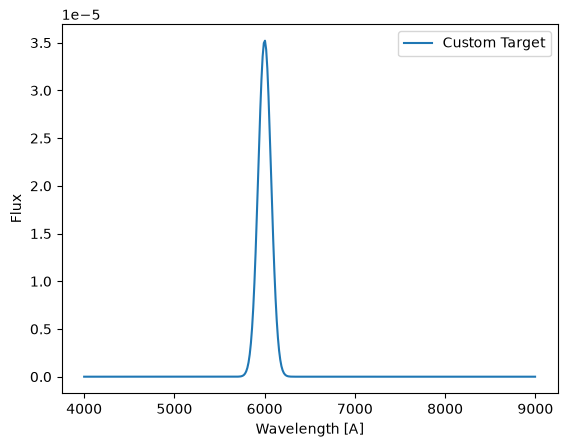

In [28]:
fig, ax = plt.subplots()
ax.plot(lbda, scene_custom.pointsource.get_spectrum(lbda=lbda)[1], label='Custom Target')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux')
ax.legend()
plt.show()

## 5. Updating `Scene` parameters

In [30]:
lbda_plot, flux_before = scene.pointsource.get_spectrum(lbda=lbda, phase=0)

In [31]:
scene.update(target__phase=10)

In [33]:
lbda_plot, flux_after = scene.pointsource.get_spectrum(lbda=lbda)

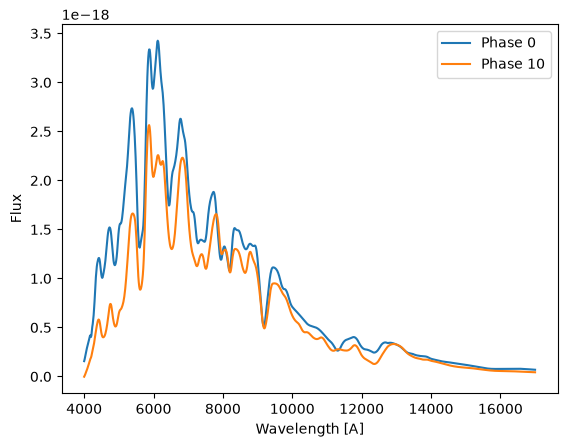

In [34]:
fig, ax = plt.subplots()
ax.plot(lbda_plot, flux_before, label='Phase 0')
ax.plot(lbda_plot, flux_after, label='Phase 10')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux')
ax.legend()
plt.show()